# Bird Species Observation Analysis

In [18]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import numpy as np
import seaborn as sns

forest_file = "E:/Analytics PDF/Bird Species Observation Analysis/Bird_Monitoring_Data_FOREST.XLSX"
grass_file = "E:/Analytics PDF/Bird Species Observation Analysis/Bird_Monitoring_Data_GRASSLAND.XLSX"

forest_xls = pd.ExcelFile(forest_file)
grass_xls = pd.ExcelFile(grass_file)

print(forest_xls.sheet_names)
print(grass_xls.sheet_names)

['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']
['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']


In [19]:
# Load sheets into dicts --

forest_data = {}
grass_data = {}

for sheet in forest_xls.sheet_names:
    forest_data[sheet] = pd.read_excel(forest_xls, sheet_name=sheet)

for sheet in grass_xls.sheet_names:
    grass_data[sheet] = pd.read_excel(grass_xls, sheet_name=sheet)

In [20]:
forest_list = []
grass_list = []

# Forest
for name, df in forest_data.items():
    df['Admin_Unit'] = name
    df['Habitat_Type'] = 'Forest'
    forest_list.append(df)

# Grassland
for name, df in grass_data.items():
    df['Admin_Unit'] = name
    df['Habitat_Type'] = 'Grassland'
    grass_list.append(df)

# Merge all
forest_df = pd.concat(forest_list, ignore_index=True)
grass_df = pd.concat(grass_list, ignore_index=True)

'''df = pd.concat([forest_df, grass_df], ignore_index=True)

print(df.shape)
df.head()'''

'df = pd.concat([forest_df, grass_df], ignore_index=True)\n\nprint(df.shape)\ndf.head()'

In [21]:
# Data Cleaning


# ── Preprocessing helper function (applied individually) ─────────────

def preprocess(df):
    # Remove duplicates
    df.drop_duplicates(inplace=True)

    # Convert date/time
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
    df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')

    # Extract hour
    df['Hour'] = df['Start_Time'].dt.hour

    # Handle missing values
    df['Sex'] = df['Sex'].fillna('Unknown')
    df['Flyover_Observed'] = df['Flyover_Observed'].fillna(False)
    df['Temperature'] = df['Temperature'].fillna(df['Temperature'].median())
    df['Humidity'] = df['Humidity'].fillna(df['Humidity'].median())

    return df

# ── Apply preprocessing individually ────────────────────────────────
forest_df = preprocess(forest_df)
grass_df  = preprocess(grass_df)

# ── Final merge ──────────────────────────────────────────────────────
df = pd.concat([forest_df, grass_df], ignore_index=True)

print(df.shape)
df.head()


# preprocessing after Merging the Datasets -- 

'''
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date/time
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')

# Fix Start_Time format properly
#df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

# Extract Hour AFTER conversion
df['Hour'] = df['Start_Time'].dt.hour

# Check if working
print(df['Hour'].isnull().sum())

# Convert time safely
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='%H:%M:%S', errors='coerce')

# If still null, try general parsing
df['Start_Time'] = df['Start_Time'].fillna(pd.to_datetime(df['Start_Time'], errors='coerce'))

df['Hour'] = df['Start_Time'].dt.hour

# Handle missing values
df['Sex'].fillna('Unknown', inplace=True)
df['Flyover_Observed'].fillna(False, inplace=True)

df['Temperature'].fillna(df['Temperature'].median(), inplace=True)
df['Humidity'].fillna(df['Humidity'].median(), inplace=True)'''



(15372, 34)


"\n# Remove duplicates\ndf.drop_duplicates(inplace=True)\n\n# Convert date/time\ndf['Date'] = pd.to_datetime(df['Date'], errors='coerce')\ndf['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')\ndf['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')\n\n# Fix Start_Time format properly\n#df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')\n\n# Extract Hour AFTER conversion\ndf['Hour'] = df['Start_Time'].dt.hour\n\n# Check if working\nprint(df['Hour'].isnull().sum())\n\n# Convert time safely\ndf['Start_Time'] = pd.to_datetime(df['Start_Time'], format='%H:%M:%S', errors='coerce')\n\n# If still null, try general parsing\ndf['Start_Time'] = df['Start_Time'].fillna(pd.to_datetime(df['Start_Time'], errors='coerce'))\n\ndf['Hour'] = df['Start_Time'].dt.hour\n\n# Handle missing values\ndf['Sex'].fillna('Unknown', inplace=True)\ndf['Flyover_Observed'].fillna(False, inplace=True)\n\ndf['Temperature'].fillna(df['Temperature'].median(), inplace=True)\ndf['Hu

In [22]:
# Post-merge validation --

print(f"Duplicates after merge: {df.duplicated().sum()}")
print(df.isnull().sum())
print(df.dtypes)

Duplicates after merge: 0
Admin_Unit_Code                    0
Sub_Unit_Code                  14650
Site_Name                       6826
Plot_Name                          0
Location_Type                      0
Year                               0
Date                               0
Start_Time                     15372
End_Time                       15372
Observer                           0
Visit                              0
Interval_Length                    0
ID_Method                          2
Distance                         689
Flyover_Observed                   0
Sex                                0
Common_Name                        0
Scientific_Name                    0
AcceptedTSN                       28
NPSTaxonCode                    6826
AOU_Code                           0
PIF_Watchlist_Status               0
Regional_Stewardship_Status        0
Temperature                        0
Humidity                           0
Sky                                0
Wind        

In [23]:
# FIX TIME COLUMN
print(df[['Start_Time', 'Hour']].head(10))

# Time Category Analysis (Morning / Afternoon / Evening)
def get_time_period(hour):
    if pd.isna(hour):
        return "Unknown"
    elif hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    else:
        return "Evening"

df['Time_Period'] = df['Hour'].apply(get_time_period)

  Start_Time  Hour
0        NaT   NaN
1        NaT   NaN
2        NaT   NaN
3        NaT   NaN
4        NaT   NaN
5        NaT   NaN
6        NaT   NaN
7        NaT   NaN
8        NaT   NaN
9        NaT   NaN


# EDA (Exploratory Data Analysis)

Admin_Unit
ANTI    3463
MONO    2522
PRWI    2463
CHOH    2202
MANA    1901
CATO     805
NACE     684
HAFE     530
GWMP     386
ROCR     289
WOTR     127
Name: Common_Name, dtype: int64


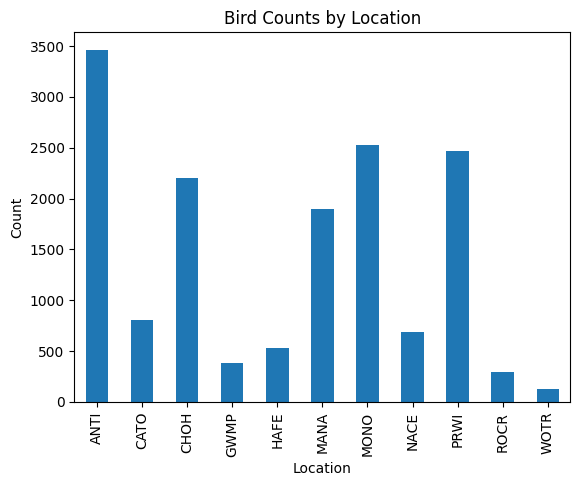

In [35]:
# Birds Count by Location

print(df.groupby('Admin_Unit')['Common_Name'].count().sort_values(ascending=False))

location_counts = df.groupby('Admin_Unit')['Common_Name'].count()

plt.figure()
location_counts.plot(kind='bar')
plt.title("Bird Counts by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()


Common_Name
Northern Cardinal          1125
Carolina Wren               993
Red-eyed Vireo              738
Eastern Tufted Titmouse     720
Indigo Bunting              611
Eastern Wood-Pewee          574
Field Sparrow               492
Red-bellied Woodpecker      489
American Robin              470
Acadian Flycatcher          462
Name: count, dtype: int64


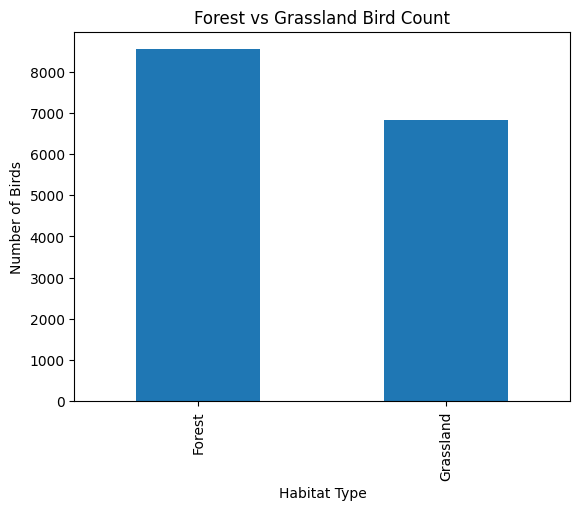

In [36]:
# Forest vs Grassland

print(df['Common_Name'].value_counts().head(10))

habitat_counts = df.groupby('Habitat_Type')['Common_Name'].count()

plt.figure()
habitat_counts.plot(kind='bar')
plt.title("Forest vs Grassland Bird Count")
plt.xlabel("Habitat Type")
plt.ylabel("Number of Birds")
plt.show()

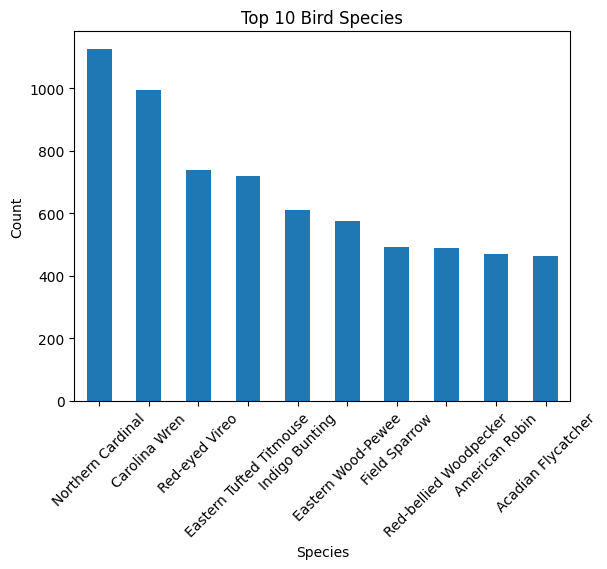

In [26]:
# Birds Count by Year & Month

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.groupby('Year')['Common_Name'].count()
df.groupby('Month')['Common_Name'].count()

# Top 10 Bird Species
top_species = df['Common_Name'].value_counts().head(10)

plt.figure()
top_species.plot(kind='bar')
plt.title("Top 10 Bird Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

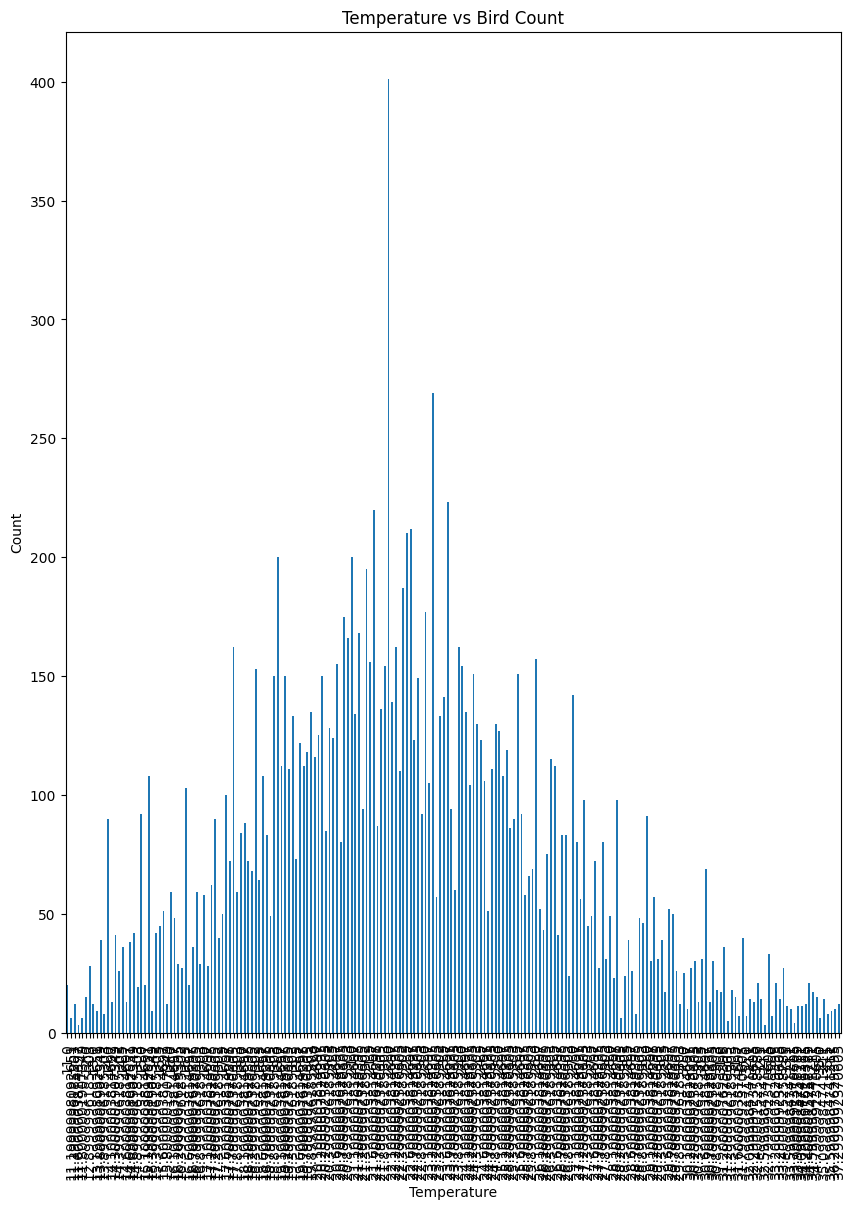

In [27]:
# Weather vs Bird Activity

df.groupby('Temperature')['Common_Name'].count()
df.groupby('Humidity')['Common_Name'].count()

temp_effect = df.groupby('Temperature')['Common_Name'].count()

plt.figure()
temp_effect.plot(kind='bar', figsize = (10,13))
plt.title("Temperature vs Bird Count")
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.show()

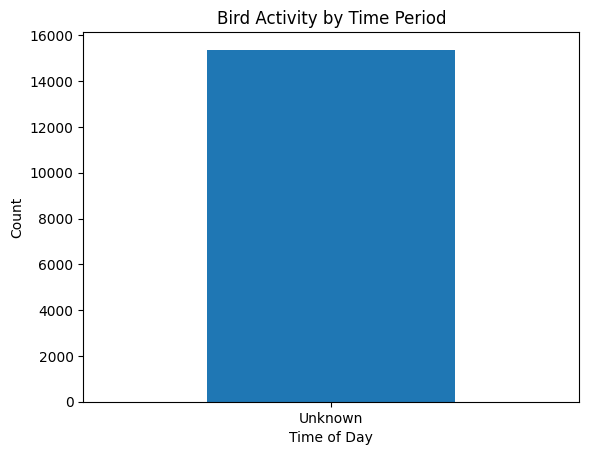

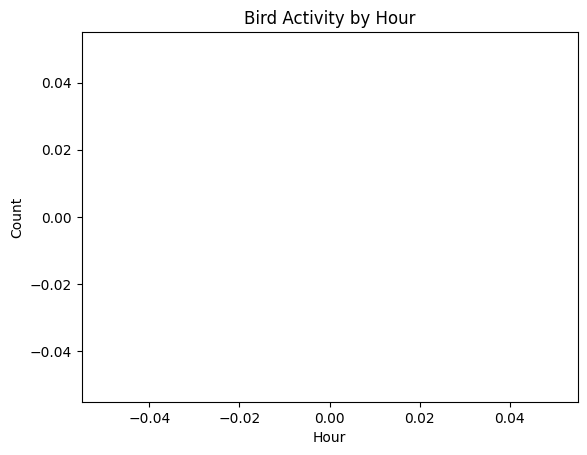

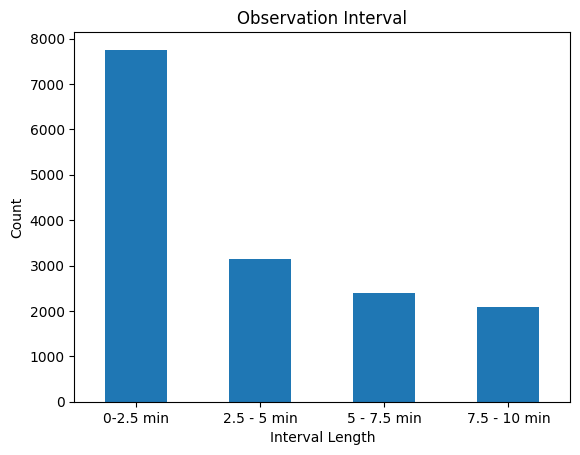

In [28]:
# Time Analysis
# Bird Activity by Hour (Time Analysis)

df['Hour'] = df['Start_Time'].dt.hour

df.groupby('Hour')['Common_Name'].count()

#df['Hour'] = df['Start_Time'].dt.hour

time_period = df['Time_Period'].value_counts()

plt.figure()
time_period.plot(kind='bar')
plt.title("Bird Activity by Time Period")
plt.xlabel("Time of Day")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.show()

hourly_activity = df.groupby('Hour')['Common_Name'].count().dropna()

plt.figure()
hourly_activity.plot(kind='line', marker='o')
plt.title("Bird Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

# Observation Duration (Interval)
interval = df['Interval_Length'].value_counts()

plt.figure()
interval.plot(kind='bar')
plt.title("Observation Interval")
plt.xlabel("Interval Length")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()



Total Unique Species: 127


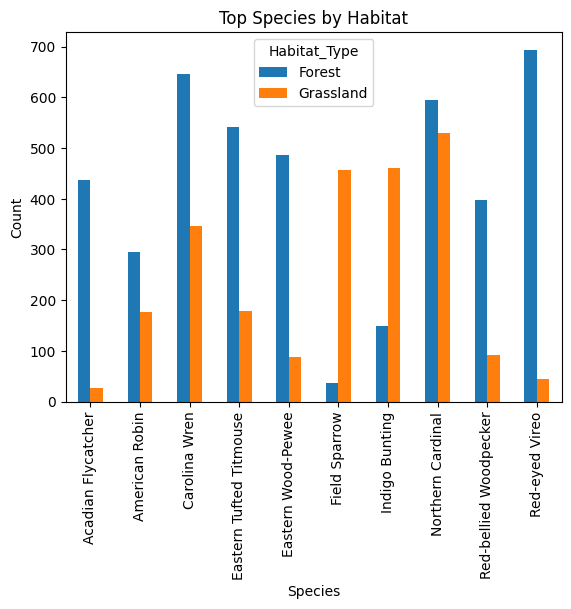

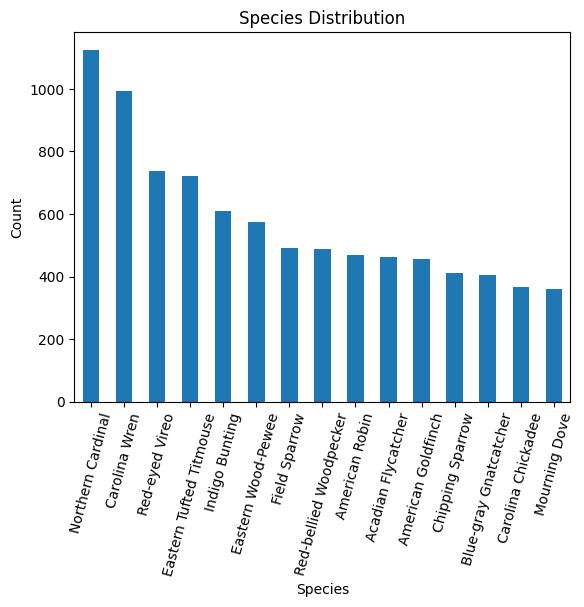

In [29]:
# Species Analysis

# Unique species
df['Scientific_Name'].nunique()

# Top species
df['Common_Name'].value_counts().head(10)

unique_species = df['Scientific_Name'].nunique()
print("Total Unique Species:", unique_species)

#Top Species by Habitat

top_species = df['Common_Name'].value_counts().head(10).index

filtered = df[df['Common_Name'].isin(top_species)]

species_habitat = filtered.groupby(['Common_Name', 'Habitat_Type']).size().unstack()

species_habitat.plot(kind='bar')
plt.title("Top Species by Habitat")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show() 

# Species Distribution

species_dist = df['Common_Name'].value_counts().head(15)

plt.figure()
species_dist.plot(kind='bar')
plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

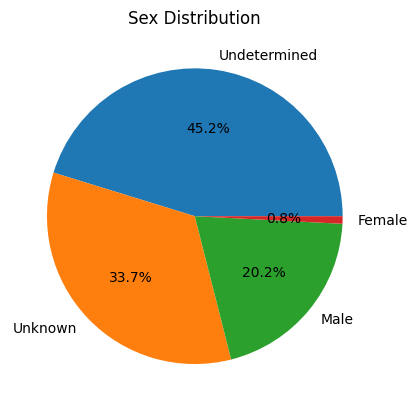

In [30]:
# Sex Ratio Analysis

sex_ratio = df['Sex'].value_counts()

plt.figure()
sex_ratio.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sex Distribution")
plt.ylabel("")
plt.show()

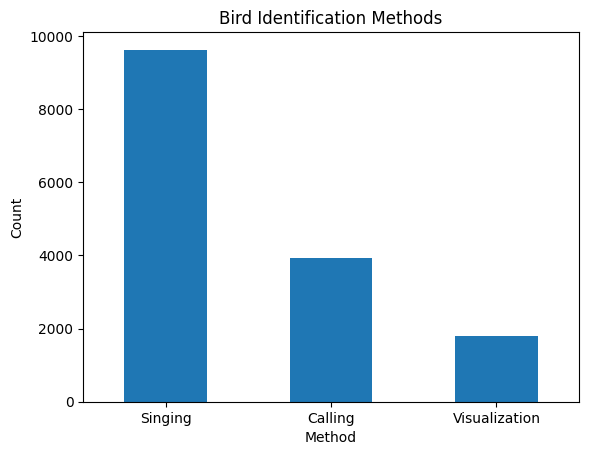

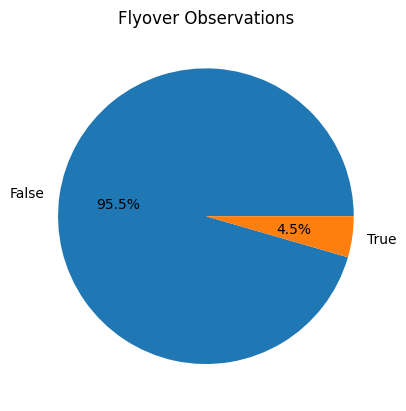

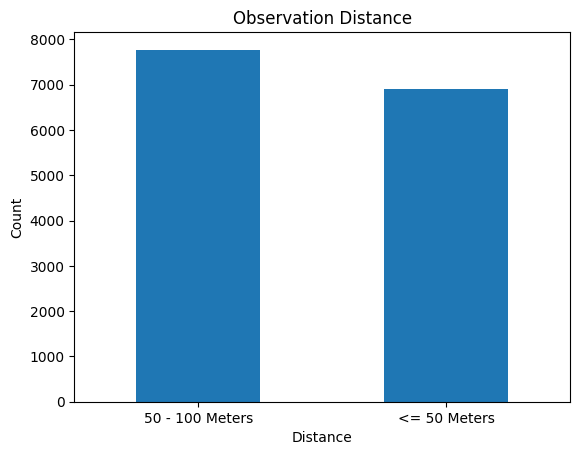

In [31]:
# Behavior Analysis

df['ID_Method'].value_counts()

df['Flyover_Observed'].value_counts()

id_method = df['ID_Method'].value_counts()

plt.figure()
id_method.plot(kind='bar')
plt.title("Bird Identification Methods")
plt.xlabel("Method")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Flyover Behavior
flyover = df['Flyover_Observed'].value_counts()

plt.figure()
flyover.plot(kind='pie', autopct='%1.1f%%')
plt.title("Flyover Observations")
plt.ylabel("")
plt.show()

# Distance Analysis

distance = df['Distance'].value_counts()

plt.figure()
distance.plot(kind='bar')
plt.title("Observation Distance")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

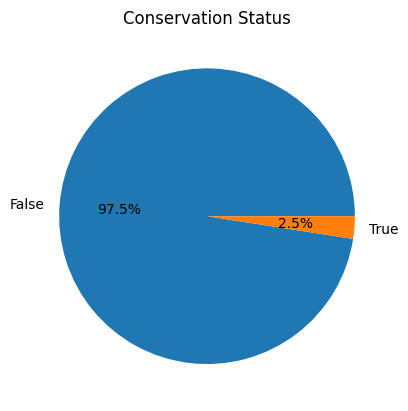

In [32]:
# Conservation Analysis

df['PIF_Watchlist_Status'].value_counts()
df['Regional_Stewardship_Status'].value_counts()

watchlist = df['PIF_Watchlist_Status'].value_counts()

plt.figure()
watchlist.plot(kind='pie', autopct='%1.1f%%')
plt.title("Conservation Status")
plt.ylabel("")
plt.show()

In [33]:
df.to_csv("cleaned_bird_data.csv", index=False, encoding='utf-8')


In [34]:
df = pd.read_csv("cleaned_bird_data.csv")
print(len(df.columns))
print(df.columns)

36
Index(['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name',
       'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer',
       'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed',
       'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt', 'Admin_Unit', 'Habitat_Type', 'Hour',
       'TaxonCode', 'Previously_Obs', 'Time_Period', 'Month'],
      dtype='str')
